# ***EDA (Exploratory Data Analysis) — World Cup Dataset***


# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

- These libraries are used for data handling, numerical analysis, and visualization.

# Load the Dataset

In [3]:
df = pd.read_csv("C:/Users/HP/Downloads/worldcup dataset.csv")
df

,date,host,stadium,match_type,team_1,team_2,team_1_score,team_2_score,winner,margin,margin_type,winning_condition,series,season,season_winner
0,30-May-19,England,The Oval,1st match,England,South Africa,311 for 8,207,England,104,runs,NaN,ICC Cricket World Cup,2019,England
1,31-May-19,England,Nottingham,2nd match,Pakistan,West Indies,105,108 for 3,West Indies,7,wickets,with 218 balls remaining,ICC Cricket World Cup,2019,England
2,1-Jun-19,England,Cardiff,3rd match,Sri Lanka,New Zealand,136,137 for 0,New Zealand,10,wickets,with 203 balls remaining,ICC Cricket World Cup,2019,England
3,1-Jun-19,England,Bristol,4th match (D/N),Afghanistan,Australia,207,209 for 3,Australia,7,wickets,with 91 balls remaining,ICC Cricket World Cup,2019,England
4,2-Jun-19,England,The Oval,5th match,Bangladesh,South Africa,330 for 6,309 for 8,Bangladesh,21,runs,NaN,ICC Cricket World Cup,2019,England
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,20-Apr-07,West Indies,Super Eights,47th Match,Australia,New Zealand,348 for 6,133,Australia,215,runs,NaN,ICC World Cup,2006/07,Australia
450,21-Apr-07,West Indies,Super Eights,48th Match,West Indies,England,300,301 for 9,England,1,wicket,with 1 ball remaining,ICC World Cup,2006/07,Australia
451,24-Apr-07,West Indies,Kingston,1st Semi-Final,Sri Lanka,New Zealand,289 for 5,208,Sri Lanka,81,runs,NaN,ICC World Cup,2006/07,Australia
452,25-Apr-07,West Indies,Gros Islet,2nd Semi-Final,South Africa,Australia,149,153 for 3,Australia,7,wickets,with 111 balls remaining,ICC World Cup,2006/07,Australia


- The dataset contains World Cup match records, including teams, scores, winners, margins, venues, and seasons.

# Check Dataset Shape

In [4]:
df.shape

(454, 15)

- The dataset contains 454 rows and 15 columns.

# Display Column Names

In [7]:
df.columns

Index(['date', 'host', 'stadium', 'match_type', 'team_1', 'team_2',
       'team_1_score', 'team_2_score', 'winner', 'margin', 'margin_type',
       'winning_condition', 'series', 'season', 'season_winner'],
      dtype='object')

- The dataset contains information about match date, host, stadium, teams, scores, winner, margin, winning condition, series, and season.

# Check Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               454 non-null    object
 1   host               454 non-null    object
 2   stadium            454 non-null    object
 3   match_type         454 non-null    object
 4   team_1             454 non-null    object
 5   team_2             454 non-null    object
 6   team_1_score       445 non-null    object
 7   team_2_score       440 non-null    object
 8   winner             454 non-null    object
 9   margin             454 non-null    object
 10  margin_type        454 non-null    object
 11  winning_condition  219 non-null    object
 12  series             454 non-null    object
 13  season             454 non-null    object
 14  season_winner      454 non-null    object
dtypes: object(15)
memory usage: 53.3+ KB


- This step shows the data types and helps identify columns that may require conversion before numerical analysis.

# Check Missing Values

In [9]:
df.isnull().sum()

date                   0
host                   0
stadium                0
match_type             0
team_1                 0
team_2                 0
team_1_score           9
team_2_score          14
winner                 0
margin                 0
margin_type            0
winning_condition    235
series                 0
season                 0
season_winner          0
dtype: int64

- This identifies missing values in each column and helps determine whether data cleaning is required.

# Check Duplicate Records

In [10]:
df.duplicated().sum()

np.int64(0)

- This checks whether any match records are repeated in the dataset.

# Generate Statistical Summary

In [11]:
df.describe(include="all")

,date,host,stadium,match_type,team_1,team_2,team_1_score,team_2_score,winner,margin,margin_type,winning_condition,series,season,season_winner
count,454,454,454,454,454,454,445,440,454,454,454,219,454,454,454
unique,312,8,96,142,19,20,381,361,20,143,10,116,6,12,6
top,13-Jun-83,England,Super Eights,7th Match,Australia,New Zealand,136,221,Australia,7,runs,D/L method,ICC World Cup,2002/03,Australia
freq,4,105,24,11,58,56,4,6,69,47,231,20,147,54,223


- The summary provides an overview of the dataset, including counts, unique values, and frequently occurring categories.

# **Data Cleaning**

# Convert Score Columns to Numeric

In [12]:
df["team_1_score"] = pd.to_numeric(df["team_1_score"], errors="coerce")
df["team_2_score"] = pd.to_numeric(df["team_2_score"], errors="coerce")

df[["team_1_score", "team_2_score"]].head()

,team_1_score,team_2_score
0,NaN,207.0
1,105.0,NaN
2,136.0,NaN
3,207.0,NaN
4,NaN,NaN


- The score columns are converted into numerical format so that averages, maximums, minimums, and comparisons can be performed.

# Convert Season to Numeric

In [13]:
df["season"] = pd.to_numeric(df["season"], errors="coerce")

df["season"].head()

0    2019.0
1    2019.0
2    2019.0
3    2019.0
4    2019.0
Name: season, dtype: float64

- The season column is converted into numeric format for easier year-based analysis.

# **Univariate Analysis**

# Number of Matches by Season

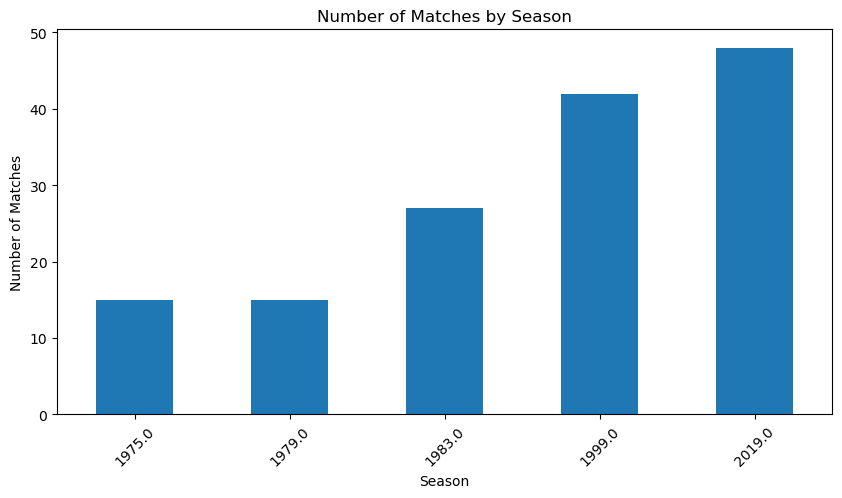

In [15]:
plt.figure(figsize=(10,5))

df["season"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Matches by Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.show()

- This graph shows how the number of recorded matches varies across different World Cup seasons.

# Most Frequent Winning Teams

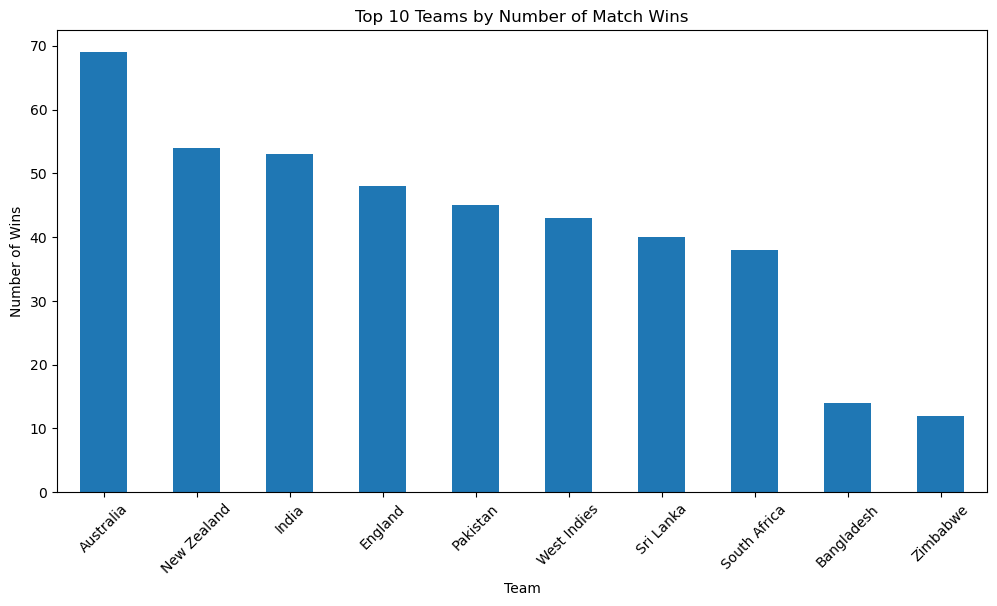

In [16]:
plt.figure(figsize=(12,6))

df["winner"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Teams by Number of Match Wins")
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45)
plt.show()

- This visualization identifies the teams that recorded the highest number of match wins in the dataset.

# Match Type Distribution

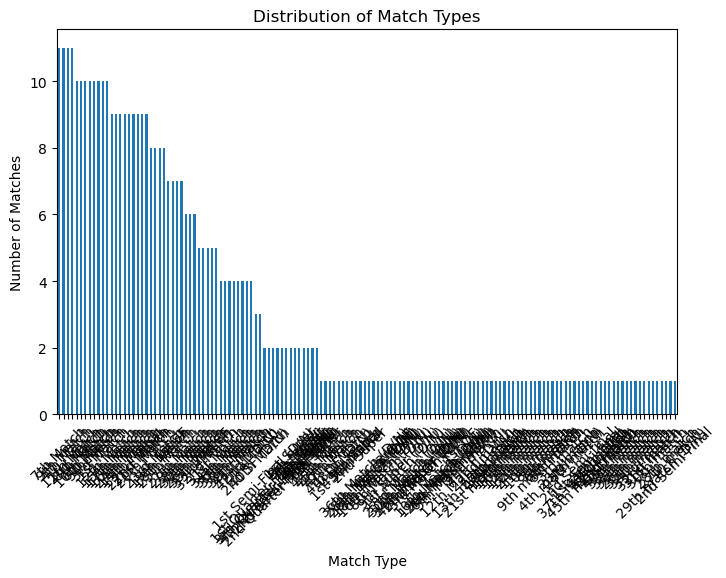

In [17]:
plt.figure(figsize=(8,5))

df["match_type"].value_counts().plot(kind="bar")

plt.title("Distribution of Match Types")
plt.xlabel("Match Type")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.show()

- The chart shows how the matches are distributed across different match types.

# Winning Conditions

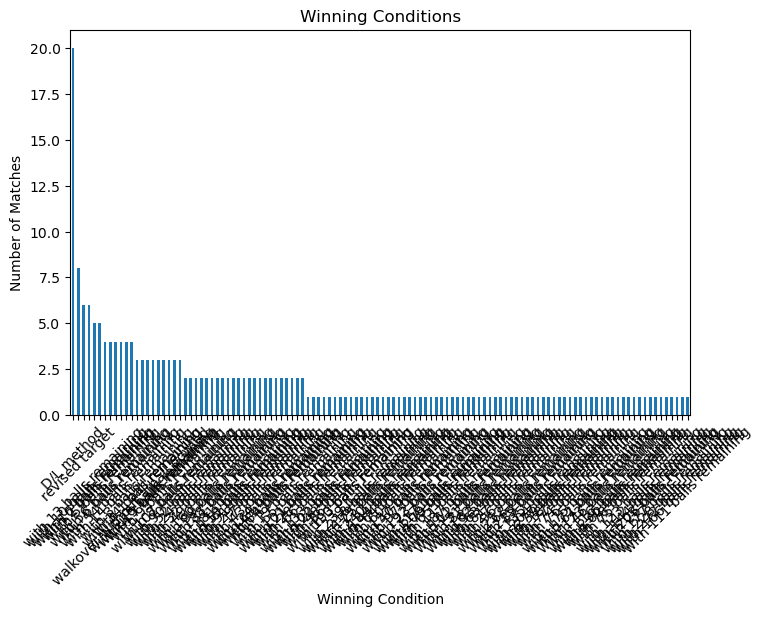

In [18]:
plt.figure(figsize=(8,5))

df["winning_condition"].value_counts().plot(kind="bar")

plt.title("Winning Conditions")
plt.xlabel("Winning Condition")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.show()

- This analysis shows the different ways teams won their matches.

# **Numerical Analysis**

# Average Team Scores

In [19]:
print("Average Team 1 Score:", df["team_1_score"].mean())
print("Average Team 2 Score:", df["team_2_score"].mean())

Average Team 1 Score: 180.09701492537314
Average Team 2 Score: 191.364161849711


- The average scores provide an overall understanding of the scoring level across the recorded matches.

# Maximum Scores

In [20]:
print("Maximum Team 1 Score:", df["team_1_score"].max())
print("Maximum Team 2 Score:", df["team_2_score"].max())

Maximum Team 1 Score: 349.0
Maximum Team 2 Score: 326.0


- This identifies the highest recorded scores for both team positions.

# Minimum Scores

In [21]:
print("Minimum Team 1 Score:", df["team_1_score"].min())
print("Minimum Team 2 Score:", df["team_2_score"].min())

Minimum Team 1 Score: 36.0
Minimum Team 2 Score: 45.0


- This helps identify the lowest recorded scores in the dataset.

# **Team Analysis**

# Team Participation

In [22]:
teams = pd.concat([df["team_1"], df["team_2"]])

team_counts = teams.value_counts()

team_counts.head(15)

Australia       96
New Zealand     91
Sri Lanka       85
India           85
England         84
West Indies     82
Pakistan        80
South Africa    64
Zimbabwe        58
Bangladesh      42
Kenya           30
Ireland         21
Netherlands     20
Canada          18
Afghanistan     15
Name: count, dtype: int64

- This shows the teams with the highest number of match appearances in the dataset.

# Top 10 Most Participating Teams

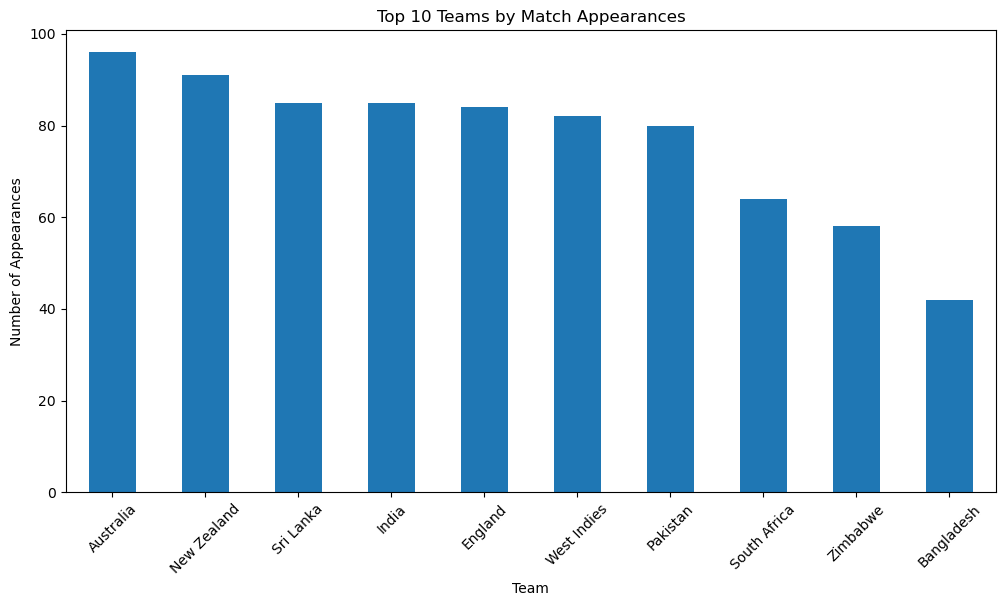

In [23]:
plt.figure(figsize=(12,6))

team_counts.head(10).plot(kind="bar")

plt.title("Top 10 Teams by Match Appearances")
plt.xlabel("Team")
plt.ylabel("Number of Appearances")
plt.xticks(rotation=45)
plt.show()

- The chart highlights the teams that appeared most frequently in the recorded World Cup matches.

# **Winner Analysis**

# Match Wins by Team

In [24]:
wins = df["winner"].value_counts()

wins.head(15)

winner
Australia                                69
New Zealand                              54
India                                    53
England                                  48
Pakistan                                 45
West Indies                              43
Sri Lanka                                40
South Africa                             38
Bangladesh                               14
Zimbabwe                                 12
No result                                 8
Ireland                                   7
Kenya                                     7
Match abandoned without a ball bowled     5
Match tied                                4
Name: count, dtype: int64

- This provides the number of matches won by each team.

# Plot Match Wins

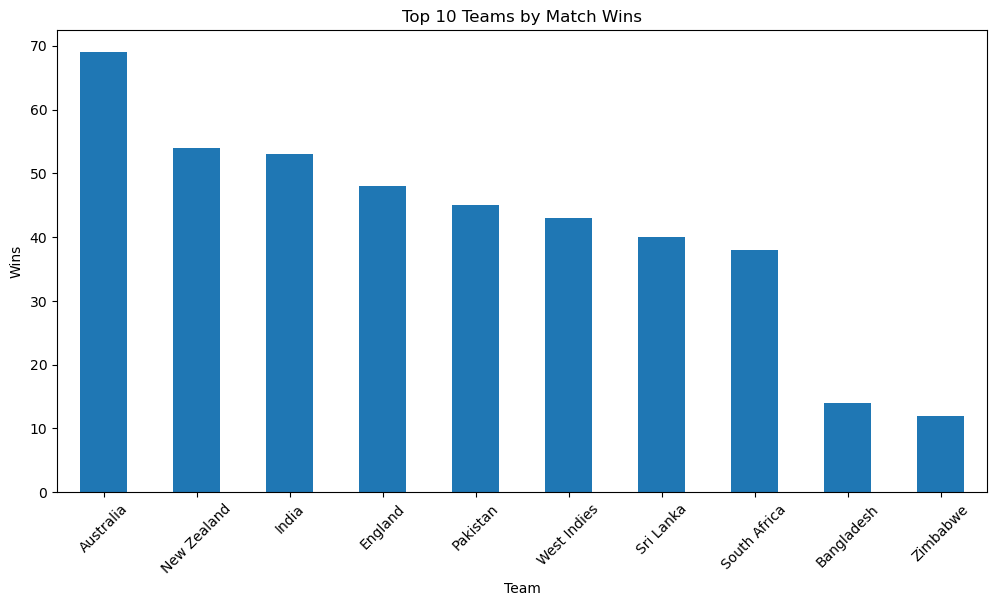

In [25]:
plt.figure(figsize=(12,6))

wins.head(10).plot(kind="bar")

plt.title("Top 10 Teams by Match Wins")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.show()

- The visualization makes it easier to compare match-winning records among the most successful teams in the dataset.

# **Season Analysis**

# Season Winners

In [26]:
season_winners = df[["season", "season_winner"]].drop_duplicates()

season_winners.sort_values("season")

,season,season_winner
205,1975.0,West Indies
38,1979.0,West Indies
63,1983.0,India
312,1999.0,Australia
0,2019.0,England
90,NaN,India
134,NaN,Australia
193,NaN,Sri Lanka
204,NaN,Pakistan


- This shows the winner associated with each World Cup season represented in the dataset

# Number of Seasons Won

In [27]:
season_winner_counts = season_winners["season_winner"].value_counts()

season_winner_counts

season_winner
West Indies    2
India          2
Australia      2
England        1
Sri Lanka      1
Pakistan       1
Name: count, dtype: int64

- This counts how many different World Cup seasons each team won according to the dataset

# Plot Season Winners

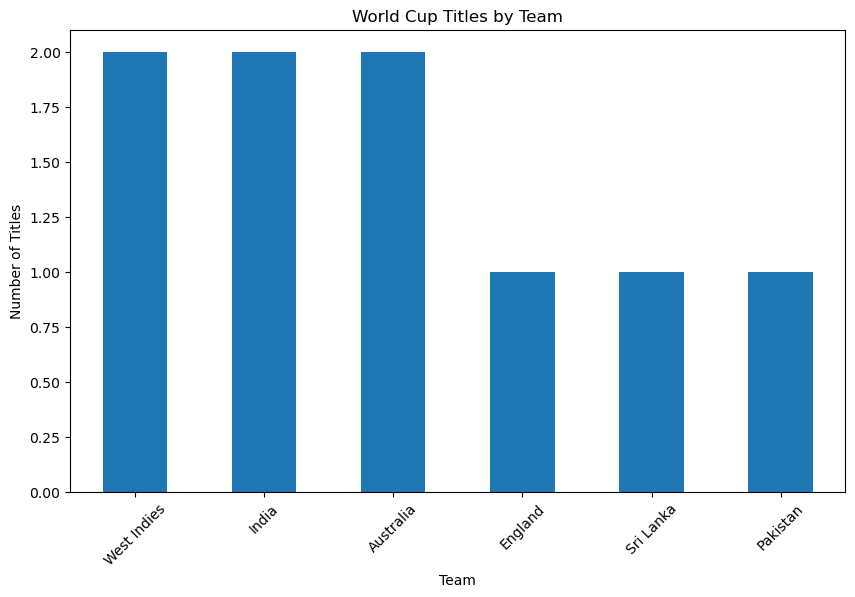

In [28]:
plt.figure(figsize=(10,6))

season_winner_counts.plot(kind="bar")

plt.title("World Cup Titles by Team")
plt.xlabel("Team")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

- The chart summarizes the distribution of World Cup titles among teams represented in the dataset.

# **Stadium Analysis**

# Matches by Stadium

In [29]:
stadium_counts = df["stadium"].value_counts()

stadium_counts.head(10)

stadium
Super Eights     24
Manchester       17
The Oval         16
Nottingham       16
Birmingham       16
Leeds            16
Lord's           15
Melbourne        10
Colombo (RPS)     9
Sydney            9
Name: count, dtype: int64

- This identifies the stadiums that hosted the largest number of recorded matches.


# Top 10 Stadiums

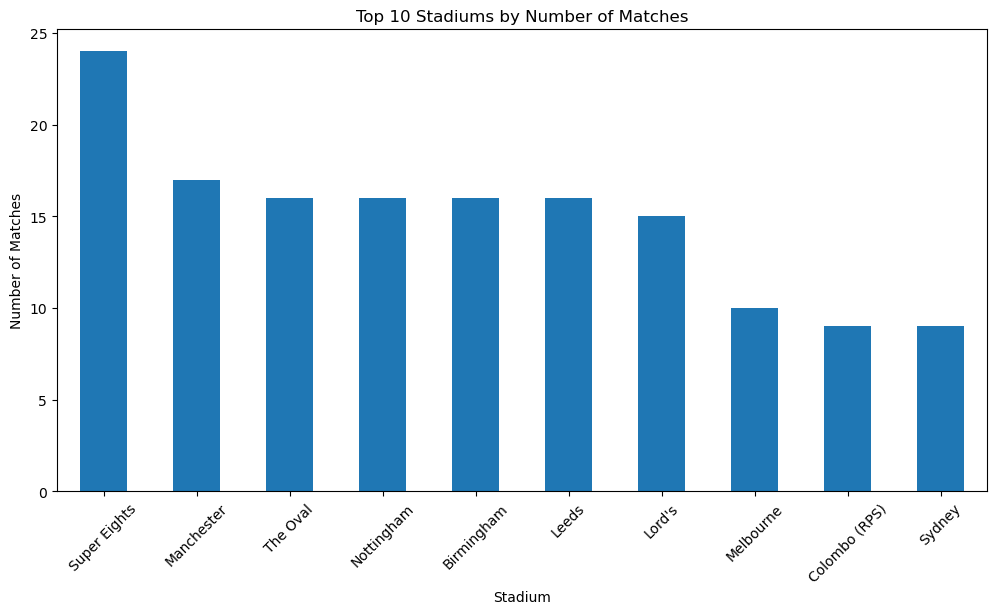

In [30]:
plt.figure(figsize=(12,6))

stadium_counts.head(10).plot(kind="bar")

plt.title("Top 10 Stadiums by Number of Matches")
plt.xlabel("Stadium")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.show()

- The visualization highlights the venues that hosted matches most frequently.

# **Host Analysis**

# Matches by Host Country

In [31]:
host_counts = df["host"].value_counts()

host_counts

host
England                                 105
Australia/New Zealand                    88
Kenya/South Africa/Zimbabwe              54
West Indies                              51
Bangladesh/India/Sri Lanka               49
England/Ireland/Netherlands/Scotland     42
India/Pakistan/Sri Lanka                 38
India/Pakistan                           27
Name: count, dtype: int64

- This shows how many recorded matches were associated with each host country.

# Host Country Visualization

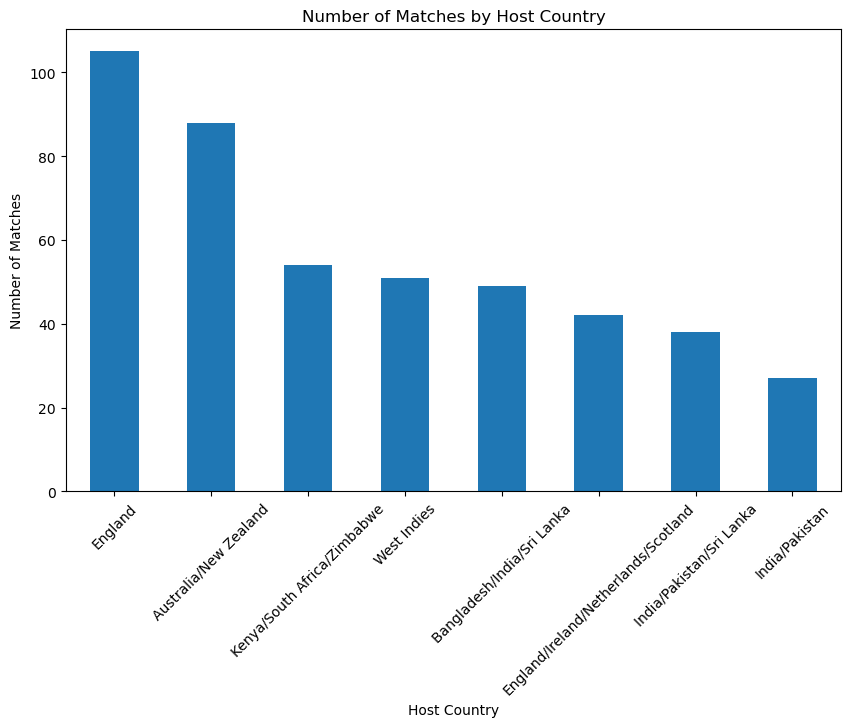

In [32]:
plt.figure(figsize=(10,6))

host_counts.plot(kind="bar")

plt.title("Number of Matches by Host Country")
plt.xlabel("Host Country")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.show()

- The chart compares the number of matches hosted by different countries.

# **Score Analysis**

# Score Distribution

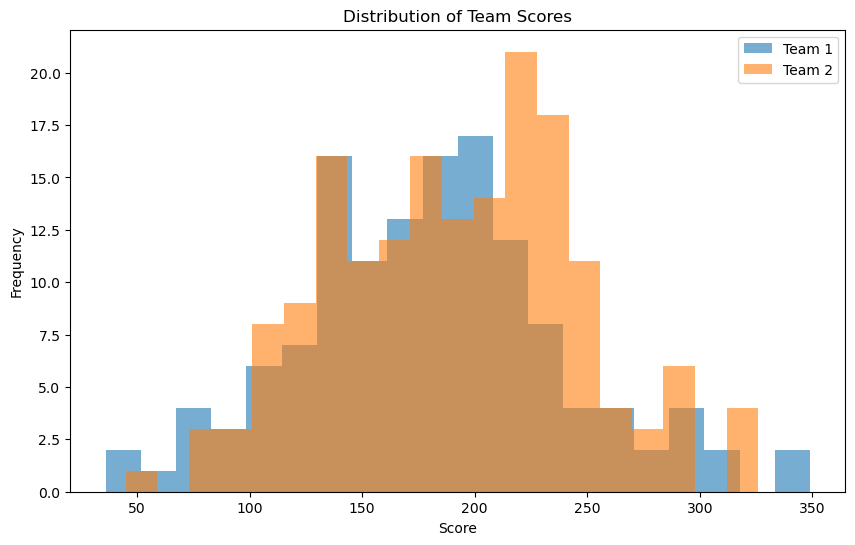

In [33]:
plt.figure(figsize=(10,6))

plt.hist(df["team_1_score"].dropna(), bins=20, alpha=0.6, label="Team 1")
plt.hist(df["team_2_score"].dropna(), bins=20, alpha=0.6, label="Team 2")

plt.title("Distribution of Team Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

- The histogram shows how frequently different scoring levels occurred across the matches.

# Boxplot of Scores

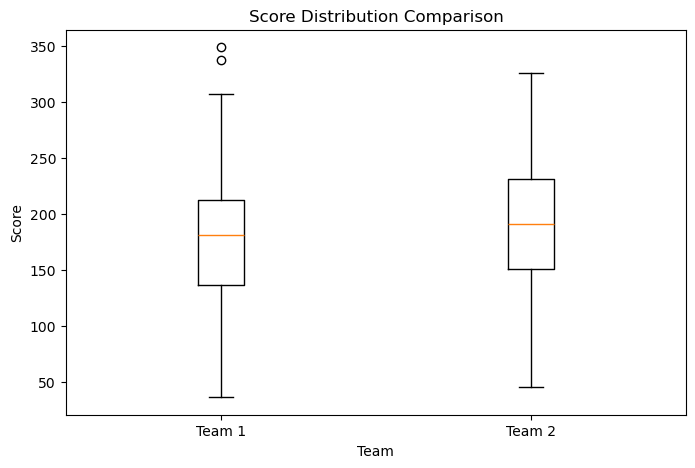

In [34]:
plt.figure(figsize=(8,5))

plt.boxplot([
    df["team_1_score"].dropna(),
    df["team_2_score"].dropna()
])

plt.title("Score Distribution Comparison")
plt.xlabel("Team")
plt.ylabel("Score")
plt.xticks([1, 2], ["Team 1", "Team 2"])
plt.show()

- The boxplot helps identify the central score range and potential unusually high or low scores.

# **Correlation Analysis**

# Correlation Between Scores

In [35]:
score_corr = df[["team_1_score", "team_2_score"]].corr()

score_corr

,team_1_score,team_2_score
team_1_score,1.000000,0.393043
team_2_score,0.393043,1.000000


- The correlation measures the relationship between the scores of Team 1 and Team 2.

# Correlation Heatmap

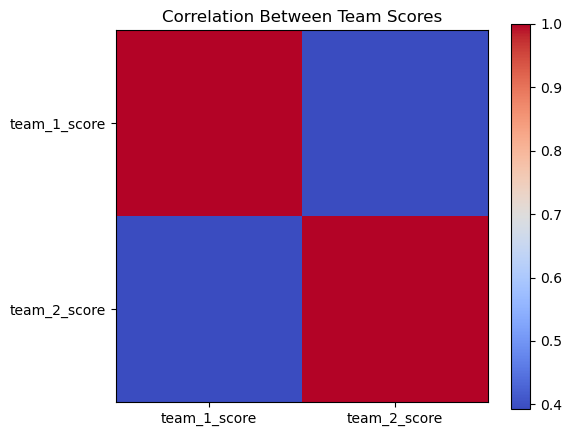

In [36]:
plt.figure(figsize=(6,5))

plt.imshow(score_corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(score_corr.columns)), score_corr.columns)
plt.yticks(range(len(score_corr.columns)), score_corr.columns)

plt.title("Correlation Between Team Scores")

plt.show()

- The heatmap provides a visual representation of the relationship between the two score variables.

# **Final EDA Summary**

# Basic Dataset Summary

In [37]:
print("Total Matches:", len(df))
print("Total Columns:", len(df.columns))
print("Total Teams:", len(set(df["team_1"].dropna()) | set(df["team_2"].dropna())))
print("Total Seasons:", df["season"].nunique())
print("Total Stadiums:", df["stadium"].nunique())
print("Total Hosts:", df["host"].nunique())

Total Matches: 454
Total Columns: 15
Total Teams: 20
Total Seasons: 5
Total Stadiums: 96
Total Hosts: 8


- This gives a compact overview of the major dimensions of the World Cup dataset.

# Final Top-Level Insights

In [38]:
print("===== WORLD CUP EDA SUMMARY =====")

print("\nTotal Matches:", len(df))

print("\nMost Frequent Winner:")
print(df["winner"].value_counts().head(5))

print("\nMost Used Stadiums:")
print(df["stadium"].value_counts().head(5))

print("\nMost Common Hosts:")
print(df["host"].value_counts().head(5))

print("\nSeason Winners:")
print(season_winners.sort_values("season"))

===== WORLD CUP EDA SUMMARY =====

Total Matches: 454

Most Frequent Winner:
winner
Australia      69
New Zealand    54
India          53
England        48
Pakistan       45
Name: count, dtype: int64

Most Used Stadiums:
stadium
Super Eights    24
Manchester      17
The Oval        16
Nottingham      16
Birmingham      16
Name: count, dtype: int64

Most Common Hosts:
host
England                        105
Australia/New Zealand           88
Kenya/South Africa/Zimbabwe     54
West Indies                     51
Bangladesh/India/Sri Lanka      49
Name: count, dtype: int64

Season Winners:
     season season_winner
205  1975.0   West Indies
38   1979.0   West Indies
63   1983.0         India
312  1999.0     Australia
0    2019.0       England
90      NaN         India
134     NaN     Australia
193     NaN     Sri Lanka
204     NaN      Pakistan


- This final output combines the major findings from the EDA into one concise summary that can be used in the conclusion of the analysis.

# **Overall Insights**

In [ ]:
The EDA of the World Cup dataset provides a clear overview of match patterns, team performance, scoring, venues, hosts, and tournament seasons. The analysis shows that some teams have significantly more match appearances and wins than others. It also highlights differences in scoring levels across matches and identifies frequently used stadiums and host countries. Season-wise analysis helps understand how tournament winners and match records have changed over time.